In [2]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
import ast
from tslearn.metrics import dtw_path
from scipy.signal import savgol_filter
import subprocess
from scipy.interpolate import interp1d
import cv2
from pandas import Series

In [3]:
def open_acc_data(filenames):
    results = []
    for filename in filenames:
        with open(filename, "r") as f:
            r = f.read()
            r = ast.literal_eval(r)
            results.append(r)
    return results

In [4]:
def delete_stationnary(data, threshold=0.002):
    #remove points at the beginning and at the end where the change is below threshold for 5 consecutive points
    start_index = 0
    end_index = len(data) - 1

    # Check for 5 consecutive stationary points at the start
    while start_index + 10 < len(data):
        stationary = True
        for i in range(5):
            if abs(data[start_index + i] - data[start_index + i + 1]) >= threshold:
                stationary = False
                break
        if stationary:
            start_index += 1
        else:
            break

    # Check for 5 consecutive stationary points at the end
    while end_index - 10 > start_index:
        stationary = True
        for i in range(5):
            if abs(data[end_index - i] - data[end_index - i - 1]) >= threshold:
                stationary = False
                break
        if stationary:
            end_index -= 1
        else:
            break

    return start_index, end_index

In [5]:
def multi_delete_stationnary(x,y,z, threshold=0.002):
    xs1, xe1 = delete_stationnary(x, threshold)
    ys1, ye1 = delete_stationnary(y, threshold)
    zs1, ze1 = delete_stationnary(z, threshold)
    s = min(xs1, ys1, zs1)
    e = min(xe1, ye1, ze1)
    new_x = x[s:e]
    new_y = y[s:e]
    new_z = z[s:e]
    return new_x, new_y, new_z

In [6]:
def smooth_moving_avg(list_of_acc_data, window_size=150):
    smoothed_data = []
    for data in list_of_acc_data:
        data_series = Series(data)
        smoothed = data_series.rolling(window=window_size, win_type="gaussian", center=True).mean(std=1)
        smoothed = smoothed.dropna().reset_index(drop=True)
        smoothed_data.append(smoothed)
    return smoothed_data

In [7]:
def compute_dense_optical_flows(video_file):

    cap = cv2.VideoCapture(video_file)
    ret, prev_frame = cap.read()
    prev_gray = cv2.cvtColor(prev_frame, cv2.COLOR_BGR2GRAY)
    flow_features = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        flow = cv2.calcOpticalFlowFarneback(prev_gray, gray, None,
                                            0.5, 3, 15, 3, 5, 1.2, 0)
        mag, ang = cv2.cartToPolar(flow[...,0], flow[...,1])
        # Features: mean magnitude, mean direction
        flow_features.append([np.mean(mag), np.mean(ang)])
        prev_gray = gray

    cap.release()
    flow_features = np.array(flow_features)  # shape: (num_frames, 2)
    return flow_features

In [8]:
def compute_histogram_video(video_file, greyscale=False, bins=256):
    """
    Compute color histograms (B, G, R) for each frame of a video.

    Args:
        video_file (str): Path to video file (e.g., .h264).
        bins (int): Number of bins for the histogram (default=256).

    Returns:
        np.ndarray: Array of shape (num_frames, bins*3),
                    where each row is the concatenated BGR histogram of a frame.
    """
    cap = cv2.VideoCapture(video_file)
    histograms = []

    if greyscale:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
    
            # Convert to grayscale
            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
    
            # Compute histogram
            hist = cv2.calcHist([gray], [0], None, [bins], [0, 256])
    
            # Normalize histogram (optional)
            hist = cv2.normalize(hist, hist).flatten()
    
            histograms.append(hist.mean())
    
        cap.release()
        return np.array(histograms).reshape(-1,1)


    else:
        while True:
            ret, frame = cap.read()
            if not ret:
                break
    
            # Compute histogram for each channel
            hist_b = cv2.calcHist([frame], [0], None, [bins], [0, 256])
            hist_g = cv2.calcHist([frame], [1], None, [bins], [0, 256])
            hist_r = cv2.calcHist([frame], [2], None, [bins], [0, 256])
    
            # Normalize histograms (optional, makes them comparable across frames)
            hist_b = cv2.normalize(hist_b, hist_b).flatten()
            hist_g = cv2.normalize(hist_g, hist_g).flatten()
            hist_r = cv2.normalize(hist_r, hist_r).flatten()
    
            # Concatenate B, G, R histograms
            hist = [hist_b.mean(), hist_g.mean(), hist_r.mean()]
            histograms.append(hist)
    
        cap.release()
        return np.array(histograms)

In [9]:
def resample_to_common_rate(acc_features, camera_features, target_rate=30, duration=20):
    """
    Resample accelerometer and camera features to a common rate.
    
    acc_features: (num_acc_samples, acc_dim)
    camera_features: (num_cam_frames, cam_dim)
    target_rate: target sampling rate in Hz
    """
    # Normalize features
    acc_features = (acc_features - acc_features.mean(0)) / acc_features.std(0)
    camera_features = (camera_features - camera_features.mean(0)) / camera_features.std(0)
    
    # Original lengths
    num_acc = acc_features.shape[0]
    num_cam = camera_features.shape[0]
    
    # Original time axes (normalized)
    acc_times = np.linspace(0, duration, num=num_acc)
    cam_times = np.linspace(0, duration, num=num_cam)
    
    # Target number of samples based on intermediate rate
    num_target = int(duration * target_rate)
    target_times = np.linspace(0, duration, num=num_target)

    # Interpolate accelerometer
    acc_resampled = np.stack([
        interp1d(acc_times, acc_features[:, i], kind='linear')(target_times)
        for i in range(acc_features.shape[1])
    ], axis=1)
    
    # Interpolate camera
    cam_resampled = np.stack([
        interp1d(cam_times, camera_features[:, i], kind='linear')(target_times)
        for i in range(camera_features.shape[1])
    ], axis=1)
    
    # Combine features
    combined = np.concatenate([acc_resampled, cam_resampled], axis=1)
    return combined

In [10]:
def plot_dtw_alignment(x1, x2, x1_label, x2_label, savename):
    plt.figure(figsize=(10, 6))
    plt.plot(x1, label=x1_label)
    plt.plot(x2, label=x2_label)
    plt.xlabel("Aligned Index")
    plt.ylabel("Value")
    plt.title("DTW Aligned Sequences")
    plt.legend()
    plt.grid(True)
    if savename: 
        plt.savefig(savename)
    plt.show()

In [11]:
def create_histogram_anim(video_file):

    width = 1280   # video width
    height = 720   # video height

    cmd = [
        "ffmpeg",
        "-i", video_file,
        "-f", "image2pipe",
        "-pix_fmt", "rgb24",
        "-vcodec", "rawvideo",
        "-"
    ]

    pipe = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.DEVNULL, bufsize=10**8)
    frame_size = width * height * 3  # RGB24

    # Prepare the plot
    fig, ax = plt.subplots()
    bins = np.arange(256)
    line, = ax.plot(bins, np.zeros(256))
    ax.set_xlim(0, 255)
    ax.set_ylim(0, width*40)
    ax.set_xlabel("Pixel value")
    ax.set_ylabel("Count")
    ax.set_title("Grayscale histogram per frame")

    def update(frame_num):
        raw_frame = pipe.stdout.read(frame_size)
        if len(raw_frame) != frame_size:
            anim.event_source.stop()
            pipe.stdout.close()
            pipe.wait()
            return line,

        frame = np.frombuffer(raw_frame, dtype=np.uint8).reshape((height, width, 3))
        gray = np.dot(frame[...,:3], [0.2989, 0.5870, 0.1140]).astype(np.uint8)
        hist, _ = np.histogram(gray, bins=256, range=(0, 255))
        hist = hist
        line.set_ydata(hist)
        return line,

    anim = FuncAnimation(fig, update, interval=30, blit=True)
    plt.show()

In [12]:
list_of_acc_data = open_acc_data(["../data/1109/x3.txt", "../data/1109/y3.txt", "../data/1109/z3.txt", "../data/1109/x4.txt", "../data/1109/y4.txt", "../data/1109/z4.txt"])

In [13]:
#x_s1, y_s1, z_s1, x_s2, y_s2, z_s2 = smooth_moving_avg(list_of_acc_data, window_size=150)

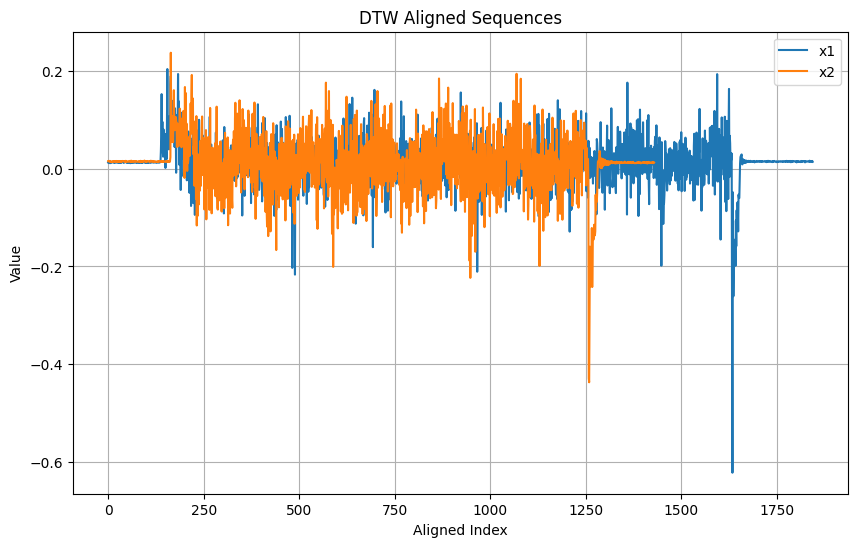

In [ ]:
plot_dtw_alignment(list_of_acc_data[1], list_of_acc_data[4], "x1", "x2", savename=None)

In [16]:
for i, data in enumerate(list_of_acc_data):
    list_of_acc_data[i] = savgol_filter(data, window_length=151, polyorder=5)
x_s1, y_s1, z_s1, x_s2, y_s2, z_s2 = list_of_acc_data

In [ ]:
plot_dtw_alignment(x_s1, x_s2, "x1", "x2", savename=None)

: 

In [173]:
print("Computing camera features 1")
ff1 = compute_dense_optical_flows("../data/1109/output_video3.h264")
print("Computing camera features 2")
ff2 = compute_dense_optical_flows("../data/1109/output_video4.h264")

Computing camera features 1
Computing camera features 2


In [153]:
print(ff1.shape)

(849, 2)


In [194]:
ff1 = compute_histogram_video("../data/1109/output_video3.h264", greyscale=True)
ff2 = compute_histogram_video("../data/1109/output_video4.h264", greyscale=True)

In [195]:
x_s1 = np.array(x_s1)
x_s2 = np.array(x_s2)
y_s1 = np.array(y_s1)
y_s2 = np.array(y_s2)
#z_s1 = np.array(z_s1)
#z_s2 = np.array(z_s2)

acc1 = np.vstack((x_s1, y_s1)).T
acc2 = np.vstack((x_s2, y_s2)).T

In [196]:
# Example usage for two runs
combined_run1 = resample_to_common_rate(acc1, ff1, target_rate=30, duration=30)
combined_run2 = resample_to_common_rate(acc2, ff2, target_rate=30, duration=30)

In [197]:
path, sim = dtw_path(combined_run1, combined_run2) #global_constraint="sakoe_chiba", sakoe_chiba_radius=10
print(f"DTW similarity: {sim}")

DTW similarity: 16.99351615365096


In [198]:
xyz1_aligned = [combined_run1[i] for i, _ in path]
xyz2_aligned = [combined_run2[j] for _, j in path]

x1_aligned = [point[0] for point in xyz1_aligned]
y1_aligned = [point[1] for point in xyz1_aligned]
#z1_aligned = [point[2] for point in xyz1_aligned]
camera1_aligned1 = [point[2] for point in xyz1_aligned]
#camera1_aligned2 = [point[3] for point in xyz1_aligned]
#camera1_aligned3 = [point[4] for point in xyz1_aligned]
x2_aligned = [point[0] for point in xyz2_aligned]
y2_aligned = [point[1] for point in xyz2_aligned]
#z2_aligned = [point[2] for point in xyz2_aligned]
camera2_aligned1 = [point[2] for point in xyz2_aligned]
#camera2_aligned2 = [point[3] for point in xyz2_aligned]
#camera2_aligned3 = [point[4] for point in xyz2_aligned]

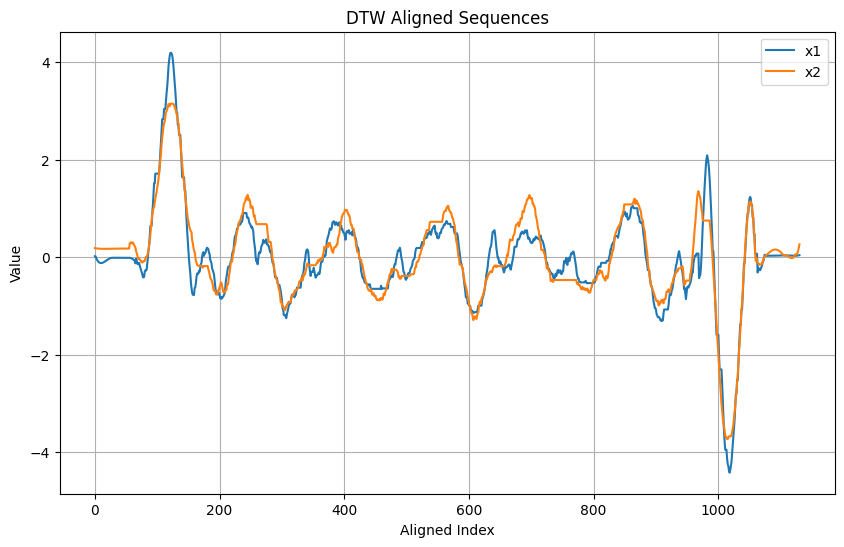

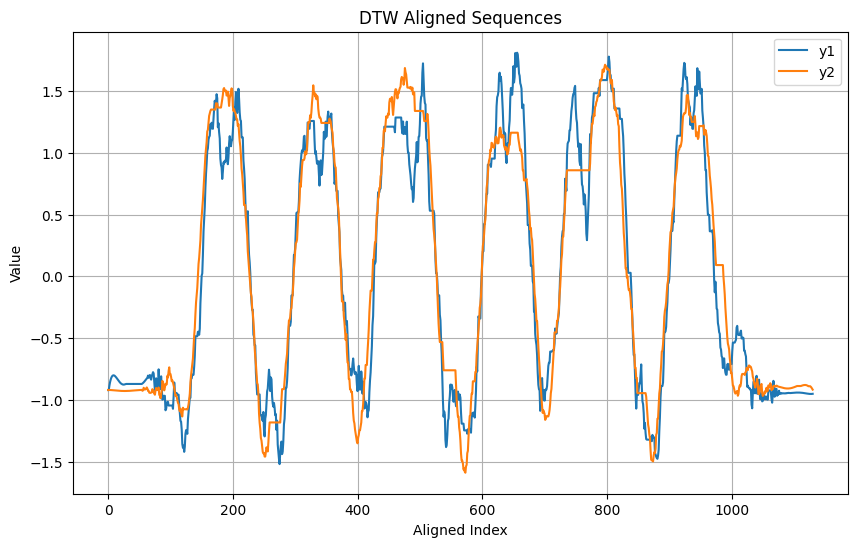

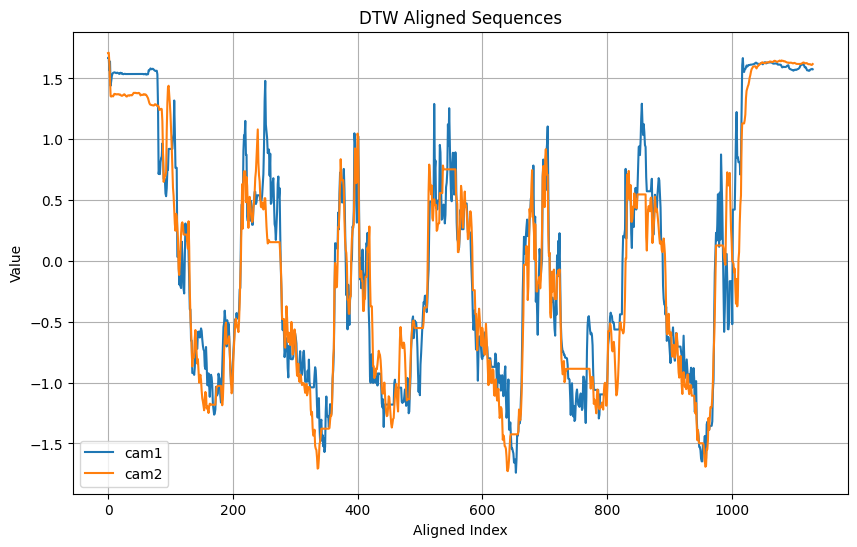

In [199]:
plot_dtw_alignment(x1_aligned, x2_aligned, "x1", "x2", savename="../results/1109/histogram_greyscale/front/dtw_x")
plot_dtw_alignment(y1_aligned, y2_aligned, "y1", "y2", savename="../results/1109/histogram_greyscale/front/dtw_y")
plot_dtw_alignment(camera1_aligned1, camera2_aligned1, "cam1", "cam2", savename="../results/1109/histogram_greyscale/front/dtw_cam")

In [37]:
ff1 = compute_histogram_video("../data/1109/output_video1.h264", greyscale=True)
ff2 = compute_histogram_video("../data/1109/output_video2.h264", greyscale=True)

In [ ]:
path, sim = dtw_path(ff1, ff2) #global_constraint="sakoe_chiba", sakoe_chiba_radius=10
print(f"DTW similarity: {sim}")

DTW similarity: 0.031847229530859084


In [ ]:
xyz1_aligned = [ff1[i] for i, _ in path]
xyz2_aligned = [ff2[j] for _, j in path]

#x1_aligned = [point[0] for point in xyz1_aligned]
#y1_aligned = [point[1] for point in xyz1_aligned]
#z1_aligned = [point[2] for point in xyz1_aligned]
#x2_aligned = [point[0] for point in xyz2_aligned]
#y2_aligned = [point[1] for point in xyz2_aligned]
#z2_aligned = [point[2] for point in xyz2_aligned]

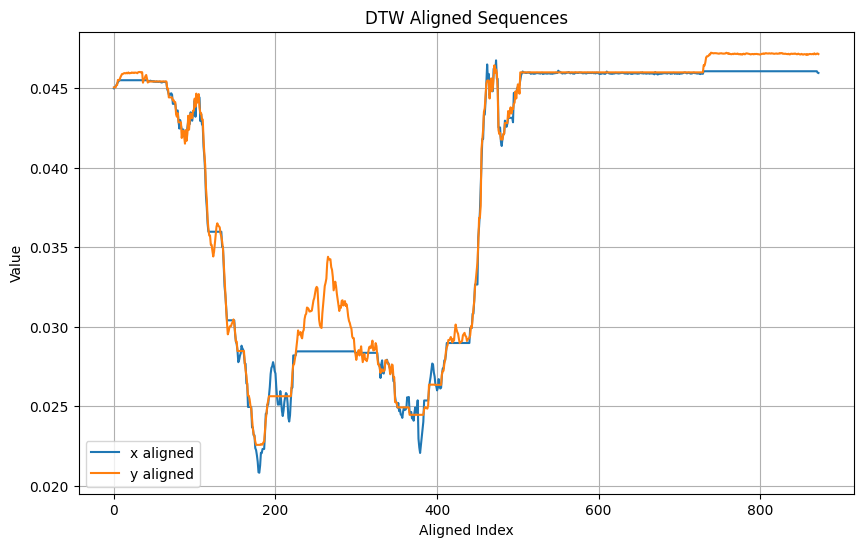

In [ ]:
plot_dtw_alignment(xyz1_aligned, xyz2_aligned)